## Supervised Learning
## Project: Finding Donors for *CharityML*

## About the Project

In this project, I have employed several supervised algorithms to accurately model individuals' income using data collected from the 1994 U.S. Census. The goal with this implementation was to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `'fnlwgt'` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `'income'`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [10]:
# Import libraries necessary for this project
#Core Libraries
import numpy as np
import pandas as pd
from pandas import get_dummies
from time import time

#Visualization imports
from IPython.display import display #for DataFrames
import visuals as vs #supplementary visuals.py script

#to ensure plots display below cells:
%matplotlib inline

#Data preprocessing and splitting
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

#Evaluation Metrics
from sklearn.metrics import accuracy_score, fbeta_score, make_scorer

#Algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

#Model Tuning
from sklearn.model_selection import GridSearchCV

In [11]:
#Load the dataset
data = pd.read_csv('census.csv')

#Success if displayed
display(data.head())

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, I computed the following:
- The total number of records, `'n_records'`
- The number of individuals making more than \$50,000 annually, `'n_greater_50k'`.
- The number of individuals making at most \$50,000 annually, `'n_at_most_50k'`.
- The percentage of individuals making more than \$50,000 annually, `'greater_percent'`.

In [12]:
#total number of records
n_records = len(data)

#Number of records where income is more than $50k
n_greater_50k = len(data[data['income']=='>50K'])

#Number of records where income is at most $50k
n_at_most_50k = len(data[data['income']=='<=50K'])

#Percentage of records where income is more than $50k
greater_percent = (n_greater_50k / n_records) * 100

#Print Results:
print(f"Total number of records: {n_records}")
print(f"Individuals making more than $50k: {n_greater_50k}")
print(f"Individuals making at most $50k: {n_at_most_50k}")
print(f"Percentage of individuals making more than $50k: {greater_percent}")

Total number of records: 45222
Individuals making more than $50k: 11208
Individuals making at most $50k: 34014
Percentage of individuals making more than $50k: 24.78439697492371


** Featureset Exploration **

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: '`capital-gain'` and `'capital-loss'`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

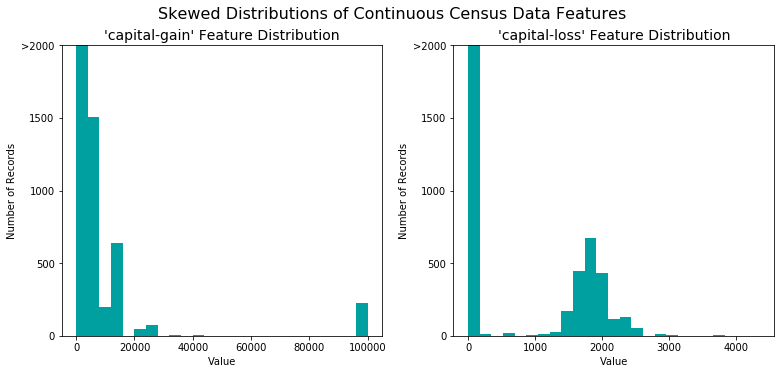

In [ ]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `'capital-gain'` and `'capital-loss'`, it is common practice to apply a <a href="https://en.wikipedia.org/wiki/Data_transformation_(statistics)">logarithmic transformation</a> on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of `0` is undefined, so we must translate the values by a small amount above `0` to apply the the logarithm successfully.

Run the code cell below to perform a transformation on the data and visualize the results. Again, note the range of values and how they are distributed. 

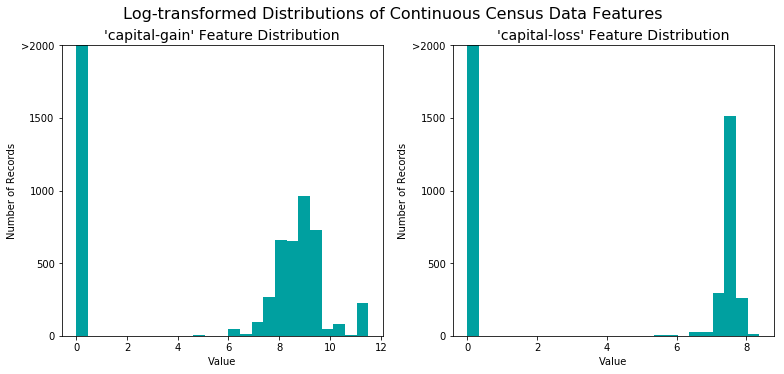

In [14]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features
In addition to performing transformations on features that are highly skewed, it is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `'capital-gain'` or `'capital-loss'` above); however, normalization ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below.

Run the code cell below to normalize each numerical feature. We will use [`sklearn.preprocessing.MinMaxScaler`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) for this.

In [15]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`. We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`.

|   | someFeature |                    | someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: |                            | :-: | :-: | :-: |
| 0 |  B  |  | 0 | 1 | 0 |
| 1 |  C  | ----> one-hot encode ----> | 0 | 0 | 1 |
| 2 |  A  |  | 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `'income'` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as `0` and `1`, respectively.

In [16]:
# TODO: One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

#Encode the 'income-raw' data to numerics
#>$50k = 1, <=$50k = 0
income = income_raw.apply(lambda x:1 if x == '>50K' else 0)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# Uncomment the following line to see the encoded feature names
print(encoded)

103 total features after one-hot encoding.
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_level_ 10th', 'education_level_ 11th', 'education_level_ 12th', 'education_level_ 1st-4th', 'education_level_ 5th-6th', 'education_level_ 7th-8th', 'education_level_ 9th', 'education_level_ Assoc-acdm', 'education_level_ Assoc-voc', 'education_level_ Bachelors', 'education_level_ Doctorate', 'education_level_ HS-grad', 'education_level_ Masters', 'education_level_ Preschool', 'education_level_ Prof-school', 'education_level_ Some-college', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ A

### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

Run the code cell below to perform this split.

In [17]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


*Note: this Workspace is running on `sklearn` v0.19. If you use the newer version (>="0.20"), the `sklearn.cross_validation` has been replaced with `sklearn.model_selection`.*

----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor
*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{precision \cdot recall}{\left( \beta^2 \cdot precision \right) + recall} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the **F$_{0.5}$ score** (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

** Accuracy ** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

** Precision ** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives(words classified as spam, and which are actually spam) to all positives(all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

`[True Positives/(True Positives + False Positives)]`

** Recall(sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives(words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

`[True Positives/(True Positives + False Negatives)]`

For classification problems that are skewed in their classification distributions like in our case, for example if we had a 100 text messages and only 2 were spam and the rest 98 weren't, accuracy by itself is not a very good metric. We could classify 90 messages as not spam(including the 2 that were spam but we classify them as not spam, hence they would be false negatives) and 10 as spam(all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score, which is weighted average(harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean as we are dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `'accuracy'` and `'fscore'` to be used later.

** Please note ** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

** HINT: ** 

* When we have a model that always predicts '1' (i.e. the individual makes more than 50k) then our model will have no True Negatives(TN) or False Negatives(FN) as we are not making any negative('0' value) predictions. Therefore our Accuracy in this case becomes the same as our Precision(True Positives/(True Positives + False Positives)) as every prediction that we have made with value '1' that should have '0' becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score(True Positives/(True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

**Answer to Question 1:**

Naive Predictor Baseline

A naive predictor establishes a performance floor for evaluating machine learning models. Without a baseline, it is impossible to determine whether a complex algorithm is genuinely learning patterns in the data or simply exploiting statistical properties of the dataset. By constructing a model that predicts every individual as earning over $50K, we create a deliberate worst-case benchmark. If a sophisticated algorithm such as AdaBoost cannot surpass this baseline, it offers no meaningful predictive improvement.

Accuracy in this context reflects the natural class distribution of the dataset. Since approximately 24% of individuals in the dataset earn over $50K, a model that predicts "yes" for every record will achieve exactly 24% accuracy,  it is correct only by coincidence, not by learning.

F-beta Score (β = 0.5) is the preferred metric here because it weights precision more heavily than recall, penalizing false positives accordingly. In the CharityML context, a false positive represents a misallocated outreach effort, contacting someone who is unlikely to donate. The naive predictor performs poorly on this metric precisely because its indiscriminate "yes" predictions generate an enormous volume of false positives, making it an appropriately harsh baseline against which to measure genuine model performance.


In [20]:
##Calculate accuracy, precision, and recall
TP = np.sum(income) #Counting the 1s
FP = income.count() - TP #Specific to naive case
TN = 0 #no predicted negatives
FN = 0 #no predicted negatives

# TODO: Calculate accuracy, precision and recall
accuracy = TP / (TP + FP)
recall = TP / (TP + FN)
precision = TP / (TP + FP)


# TODO: Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
beta = 0.5
fscore = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

#print results
print(f"Accuracy score: {accuracy}, F-score {fscore}")

Accuracy score: 0.2478439697492371, F-score 0.29172913543228385


###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [`scikit-learn`](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
I have chosen three of the supervised learning models above that are appropriate for this problem to test on the census data. For each model chosen you will find answers to the following prompts:

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?



***Random Forest Classifier:***

**Real-world application:** Predicting customer churn or identifying fraudulent credit card transactions.
**Strengths:** It handles categorical and numerical data seamlessly and is highly resistant to 'overfitting' because it averages out the predictions of hundred of independent decision trees.
**Weaknesses:** It can be computationally heavy and consume a lot of memory when the number of trees is very high.
**Why a good candidate:** Our census dataset has a mix of continuous numbers (age) and categories (workclass), which Random Forest processes well.


***AdaBoost Classifier:***

**Real-world application:** The boxes that pop up around objects detected on a phone camera made me think of facial recognition in digital images.
**Strengths:** It is fast and highly accurate. Instead of building independent trees, it builds sequential trees where each new trees where each new tree focuses specifically on fixing mistakes found on the previous one.
**Weaknesses:** It is sensitive to noisy data and extreme outliers, which throws it off its learning sequence.
**Why a good candidate:** It historically performs well on binary classification tasks (yes/no outcomes) like our income predictor.


***Gradient Boosting Classifier:***

**Real-world application:** Web search ranking algorithms or credit scoring.
**Strengths:** Often yields the highest absolute accuracy among all tree-based supervised learning models by optimizing a 'loss function'.
**Weaknesses:** It is prone to overfitting if the parameters are not carefully tuned, and it takes longest to train.
**Why a good candidate:** We aim for the highest possible F-score to ensure CharityML does not waste money nor time on people who will not donate, and Gradient Boosting is great at accurately finding this.


***Reference***

@inproceedings{sklearn_api,
  author    = {Lars Buitinck and Gilles Louppe and Mathieu Blondel and
                Fabian Pedregosa and Andreas Mueller and Olivier Grisel and
                Vlad Niculae and Peter Prettenhofer and Alexandre Gramfort
                and Jaques Grobler and Robert Layton and Jake VanderPlas and
                Arnaud Joly and Brian Holt and Ga{\"{e}}l Varoquaux},
  title     = {{API} design for machine learning software: experiences from the scikit-learn
                project},
  booktitle = {ECML PKDD Workshop: Languages for Data Mining and Machine Learning},
  year      = {2013},
  pages = {108--122},
}


### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model I've chosen, it's important that I create a training and predicting pipeline that allows me to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. The implementation here will be used in the following section.
In the code block below, I implemented the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [21]:
# TODO: Import two metrics from sklearn - fbeta_score and accuracy_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    results = {}

    #Fit the learner to the training data using slicing with sample_size
    start = time()
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time()
    results['train_time'] = end - start

    #Get predictions on test set, then predictions on test samples
    start = time()
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time()

    results['pred_time'] = end - start

    #Compute accuracy on training samples
    results['acc_train'] = accuracy_score(y_train[:300], predictions_train)

    #Compute accuracy on test set
    results['acc_test'] = accuracy_score(y_test, predictions_test)

    #Compute F-score on training samples
    results['f_train']= fbeta_score(y_train[:300], predictions_train, beta=.5)

    #Compute F-score on test set
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=.5)

    print(f"{learner.__class__.__name__} trained on {sample_size} samples")

    return results

### Implementation: Initial Model Evaluation
I implemented the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `'clf_A'`, `'clf_B'`, and `'clf_C'`.
  - Use a `'random_state'` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `'samples_1'`, `'samples_10'`, and `'samples_100'` respectively.

**Note:** This may take some time to run.

RandomForestClassifier trained on 361 samples
RandomForestClassifier trained on 3617 samples
RandomForestClassifier trained on 36177 samples
AdaBoostClassifier trained on 361 samples
AdaBoostClassifier trained on 3617 samples
AdaBoostClassifier trained on 36177 samples
GradientBoostingClassifier trained on 361 samples
GradientBoostingClassifier trained on 3617 samples
GradientBoostingClassifier trained on 36177 samples


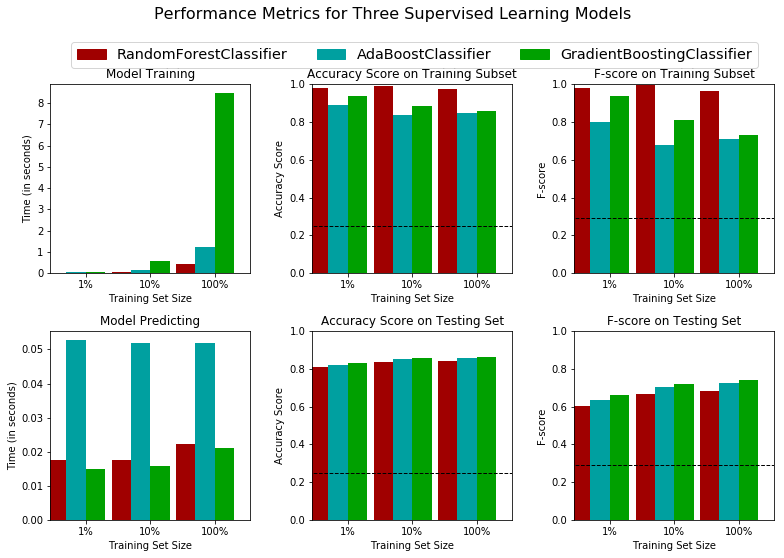

In [22]:
# TODO: Import the three supervised learning models from sklearn

##Instantiate three models

clf_rf = RandomForestClassifier(random_state=42)
clf_ada = AdaBoostClassifier(random_state=42)
clf_gb = GradientBoostingClassifier(random_state=42)

# TODO: Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
#Calculate number of samples (.01,.1,1) for training data
samples_100 = len(y_train)
samples_10 = int(len(y_train) * 0.1)
samples_1 = int(len(y_train) * 0.01)

#Collect results on learners
results = {}
for clf in [clf_rf, clf_ada, clf_gb]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
            train_predict(clf, samples, X_train, y_train, X_test, y_test)

#Run metrics visualization for three supervised learning models
vs.evaluate(results, accuracy, fscore)

----
## Improving Results
In this final section, using the three models chosen, I performed a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, we will explain to  *CharityML* which of the three models believed to be most appropriate for the task of identifying individuals that make more than \$50,000. 

** HINT: ** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score?

* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer:**

Judging by the testing set metrics, AdaBoost provided the best balance. It achieved an optimized Accuracy of ~85.68% and an F-score of ~0.7214. While Gradient Boosting sometimes matches its accuracy, AdaBoost trained and predicted significantly faster (lower computational time), making it the most efficient and scalable model for CharityML to use as their database grows.



### Question 4 - Describing the Model in Layman's Terms

* We will need to explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. 


**Answer:** 

***AdaBoost: Ensemble Learning Through Sequential Correction***

Consider the task of predicting whether an individual earns over $50K. AdaBoost approaches this by assembling a sequence of "weak" learners, models that perform only slightly better than random chance, and combining them into a single, highly accurate predictor.

The first learner trains on the dataset and produces an initial set of predictions. It will classify most cases correctly, but inevitably misclassifies some. Rather than discarding these errors, AdaBoost increases the weight of the misclassified observations, forcing the next learner to pay closer attention to the cases the first found difficult. Each subsequent learner inherits this reweighted dataset and focuses its efforts on the mistakes of its predecessor.

This sequential correction continues for a defined number of iterations. Once complete, every learner casts a weighted vote, with more accurate learners carrying greater influence, and the final prediction is determined by the aggregate of those votes.

The result is a model that progressively reduces its blind spots, turning an ensemble of individually weak classifiers into a robust and highly accurate predictor.


### Implementation: Model Tuning
I fine-tuned the chosen model using grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. I used the entire training set for this. In the code cell below, you will see the following implemented:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Initialize the classifier you've chosen and store it in `clf`.
 - Set a `random_state` if one is available to the same state you set before.
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
 - **Note:** Avoid tuning the `max_features` parameter of your learner if that parameter is available!
- Use `make_scorer` to create an `fbeta_score` scoring object (with $\beta = 0.5$).
- Perform grid search on the classifier `clf` using the `'scorer'`, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_fit`.

**Note:** Depending on the algorithm chosen and the parameter list, the following implementation may take some time to run!

In [23]:
#Instantiate classifier

clf = AdaBoostClassifier(random_state=42)

#Create parameters list to tune
parameters = {'n_estimators': [50,100,200,300],
              'learning_rate': [0.1,0.5,1.0,1.5]}

#Make an fbeta_score scoring object using make_scorer
scorer = make_scorer(fbeta_score, beta=0.5)

#Perform grid search on the classifier using 'scorer' as scoring method
grid_obj = GridSearchCV(clf, parameters, scoring=scorer)

#Fit grid search object to training data and find optimal parameters
grid_fit = grid_obj.fit(X_train, y_train)

#Get absolute best estimator from grid search
best_clf = grid_fit.best_estimator_

#Make prediction using the unoptimized and optimized models
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-after scores
print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))

Unoptimized model
------
Accuracy score on testing data: 0.8576
F-score on testing data: 0.7246

Optimized Model
------
Final accuracy score on the testing data: 0.8666
Final F-score on the testing data: 0.7432


### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?_  


#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score |        0.8576     |      0.8666     |
| F-score        |        0.7246     |      0.7432     |


**Answer:**

The optimized model's accuracy on the testing data is 0.8666, and its F-score is 0.7432. These scores are better thant he unoptimized model. By utilizing grid search to tune the hyperparameters, the model's accuracy improved from 0.8576 to 0.8666, and the F-score increased from 0.7246 to 0.7432. This proves the tuning process successfully found a more optimal mathematical boundary for the data.

When comparing the naive predictor benchmarks from Question 1, the optimized model's performance is drastically better. The naive predictor essentially made blind guesses, resulting in mostly false positives. The optimized model's massive jump in both accuracy and F-score proves that the algorithm successfully learned the underlying demographic patterns, meaning the charity will spend its marketing budget much more efficiently.


----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than \$50,000.


### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**

**My top 5 predictions for the most important features:**

Capital-gain: People with investments and capital gains usually have enough wealth to donate.

Occupation: Specific positions held by a person ties into a person's income limits.

Education-Level: Higher degrees typically unlock higher-paying professional roles.

Age: Older individuals generally have more experience and higher salaries.

Marital-Status: Two-person incomes may be more likely to have disposable income, than single counterparts.


### Implementation - Extracting Feature Importance
Next, I chose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute available for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will see the following implemented:
 - Import a supervised learning model from sklearn.
 - Trained the supervised model on the entire training set.
 - Extracted the feature importances using `'.feature_importances_'`.

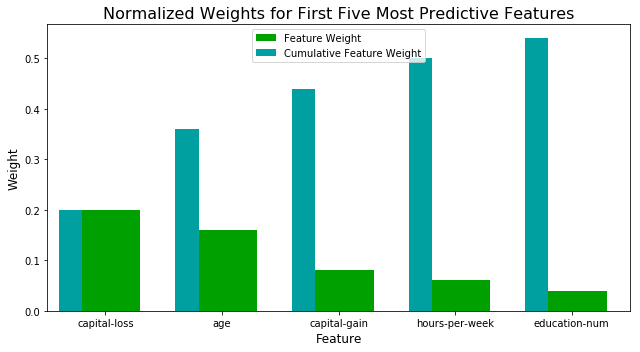

In [ ]:
# TODO: Import a supervised learning model that has 'feature_importances_'
from sklearn.ensemble import AdaBoostClassifier

# TODO: Train the supervised model on the training set using .fit(X_train, y_train)
# We instantiate the model and fit it to the training data in one step
model = AdaBoostClassifier(random_state=42).fit(X_train, y_train)

# TODO: Extract the feature importances using .feature_importances_ 
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above \$50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

**Feature Analysis and Prediction Evaluation**

Nearly all predictions from Question 6 were confirmed by the data. One initially surprising finding was the significance of hours worked per week; however, given that this dataset originates from 1994 census data, it is consistent with an era in which high-earning professions routinely demanded substantially more time than standard working hours. The visualizations largely support these initial predictions.

Capital Gain and Capital Loss emerge as strong indicators of wealth, as both require an individual to possess disposable income in the first place. The ability to invest in financial markets or property, and therefore to realize gains or losses, is itself a marker of economic standing that filters out lower-income individuals almost by definition.

Age serves as a reliable proxy for career progression. Older individuals have generally had more time to accumulate work experience, advance into senior or specialized roles, and build personal wealth, advantages that younger demographics have not yet had the opportunity to develop.

Hours Worked Per Week functions as an income multiplier. Individuals working full-time schedules with significant overtime will, in most cases, generate higher gross income than part-time workers, independent of their role or sector.

Education Level is a gateway to higher-earning opportunities. Advanced credentials expand the range of roles available to an individual, many of which carry compensation that is structurally inaccessible without them.


### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data. This hints that we can attempt to *reduce the feature space* and simplify the information required for the model to learn. The code cell below will use the same optimized model you found earlier, and train it on the same training set *with only the top five important features*. 

In [25]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8666
F-score on testing data: 0.7432

Final Model trained on reduced data
------
Accuracy on testing data: 0.8402
F-score on testing data: 0.6960


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**

Although the model trains incredibly fast on only the top 5 features, it experiences a slight drop in both Accuracy and F-score, compared to the model trained on all 13 features.

If CharityML's database was to expand to include millions of potential donors, computational cost and training time would become massive bottlenecks. In that scenario, using a dataset reduced in size is the right business decision. We see that the predictive power of the model is retained using just those 5 features. Sacrificing a tiny fraction of a percent in accuracy would be a highly efficient trade-off to save hours of processing time and computing power.